In [1]:
import numpy as np
import matplotlib.pyplot as plt
from forTP1 import Bandit

myBandit = Bandit()

#### Uniform Exploration

In [15]:
K = 4
T = 500
bandits = [[0]]
for k in range(K-1):
    bandits.append([0]) 

print(bandits)

for t in range(T):
    k = np.random.randint(0,K)
    reward = myBandit.get_arm(k)
    # print(k,reward)
    bandits[k] += reward

print(bandits)

print(np.argmax(bandits))

[[0], [0], [0], [0]]
[array([1702]), array([1639]), array([834]), array([1045])]
0


In [16]:
def Uniform_Exploration(K, T, N, plot=False):
    bandits = [[]]
    for k in range(K-1):
        bandits.append([]) 

    for n in range(N):
        for k in range(K):
            # k = np.random.randint(0,K)
            reward = myBandit.get_arm(k)
            bandits[k].append(reward)

    averages = [np.mean(sub_array) for sub_array in bandits]
    bestk = np.argmax(averages)
    

    for t in range(T-(K*N)):
        reward = myBandit.get_arm(bestk)
        bandits[bestk].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]


    if plot == True:
        print(f"Averages = {averages}")
        print(f"Best arm = {bestk}")
        print(f"Sums = {summs}")
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()

    return np.sum(summs)/T

    

Averages = [np.float64(14.44), np.float64(11.7), np.float64(6.24), np.float64(7.46), np.float64(10.06), np.float64(10.7), np.float64(5.02), np.float64(6.88), np.float64(9.4), np.float64(10.06)]
Best arm = 0
Sums = [np.int32(7755), np.int32(585), np.int32(312), np.int32(373), np.int32(503), np.int32(535), np.int32(251), np.int32(344), np.int32(470), np.int32(503)]


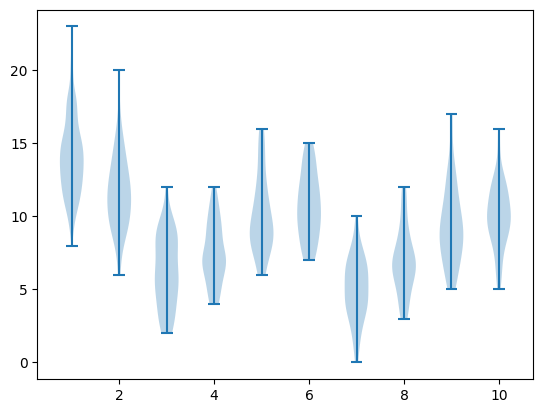

In [21]:
K = 10
T = 1000
N = 50
reward = Uniform_Exploration(K, T, N, True)

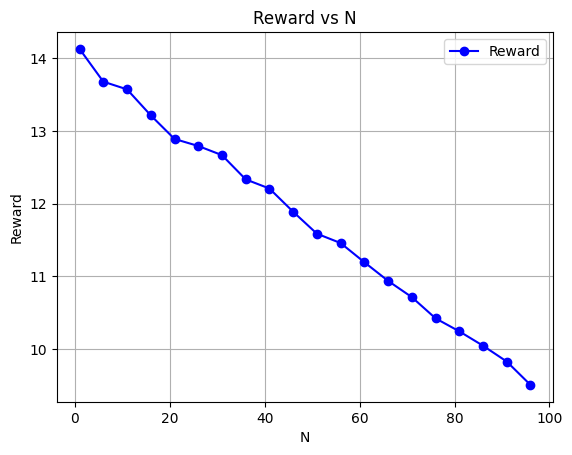

In [5]:
N_values = range(1, 100, 5)
reward_values = []

for N in N_values:
    reward = Uniform_Exploration(K, T, N)  
    reward_values.append(reward)  

plt.plot(N_values, reward_values, marker='o', linestyle='-', color='b', label='Reward')
plt.xlabel('N')
plt.ylabel('Reward')
plt.title('Reward vs N')
plt.legend()
plt.grid(True)
plt.show()

#### ε-Greedy

In [6]:
def Ep_Greedy(K, T, Epsilon, plot = False):
    bandits = [[]]
    for k in range(K-1):
        bandits.append([]) 

    for t in range(T):

        if np.random.uniform(0, 1) > Epsilon:
            meds = [np.average(sub_array) for sub_array in bandits]
            k = np.argmax(meds)
            
        else:
            k = np.random.randint(0,K)
        
        reward = myBandit.get_arm(k)
        bandits[k].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]

    if plot == True:
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()

    return np.sum(summs)/T

c:\Users\ferna\.virtualenvs\TPs_Univ-6thOmQNe\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\ferna\.virtualenvs\TPs_Univ-6thOmQNe\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


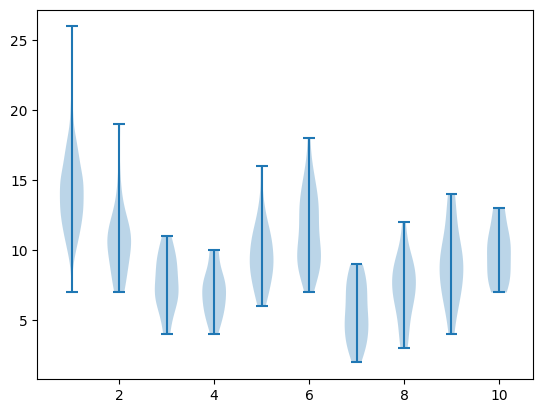

In [7]:
Epsilon = 0.2
reward = Ep_Greedy(K, T, Epsilon, True)

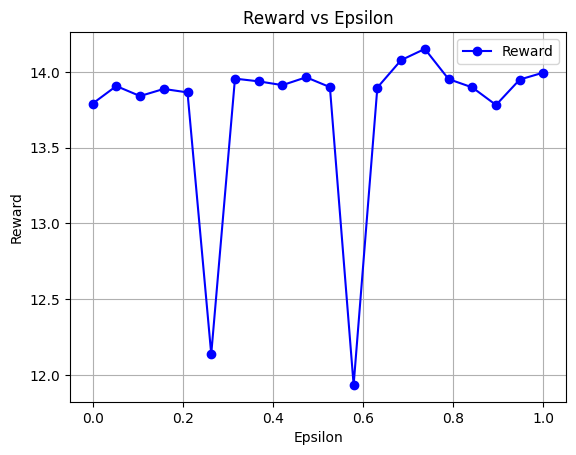

In [8]:
Ep_values = np.linspace(0, 1, 20)
reward_values = []

for ep in Ep_values:
    reward = Ep_Greedy(K, T, ep/100)  
    reward_values.append(reward)  

plt.plot(Ep_values, reward_values, marker='o', linestyle='-', color='b', label='Reward')
plt.xlabel('Epsilon')
plt.ylabel('Reward')
plt.title('Reward vs Epsilon')
plt.legend()
plt.grid(True)
plt.show()

#### Successive Elimination

In [7]:
def Adaptive_Elimination(K, T, plot=False):
    """
    Adaptive bandit elimination algorithm with exactly T total arm pulls
    
    Parameters:
    K: number of bandits
    T: total time steps (arm pulls)
    confidence_level: confidence level for confidence bounds
    plot: whether to plot the elimination process
    """
    
    # Initialize
    active_bandits = list(range(K))  # All bandits start as active
    rewards = [[] for _ in range(K)]  # Store rewards for each bandit
    elimination_timeline = []  # Track when bandits are eliminated
    total_pulls = 0
    
    while total_pulls < T and len(active_bandits) > 0:
        # Play each active bandit once (if we have enough pulls remaining)
        pulls_this_round = min(len(active_bandits), T - total_pulls)
        
        for i in range(pulls_this_round):
            k = active_bandits[i]
            reward = myBandit.get_arm(k)
            rewards[k].append(reward)
            total_pulls += 1
        
        # Check if we should eliminate any bandits (only after sufficient samples)
        if total_pulls >= 2 * K:  # Wait for at least 2 samples per bandit on average
            to_eliminate = []
            
            # Calculate confidence bounds for all active bandits
            bounds = {}
            for k in active_bandits:
                if len(rewards[k]) >= 2:  # Need at least 2 samples for std dev
                    mean_reward = np.mean(rewards[k])
                    std_dev = np.std(rewards[k], ddof=1)  # Sample standard deviation
                    n_samples = len(rewards[k])
                    
                    # # Standard error of the mean
                    sem = std_dev / np.sqrt(n_samples)
                    
                    # Confidence bounds
                    lower_bound = mean_reward - std_dev
                    upper_bound = mean_reward + std_dev
                    
                    bounds[k] = (mean_reward, lower_bound, upper_bound, n_samples)
            
            if bounds:
                # Find the bandit with the highest lower bound
                best_bandit = max(bounds.keys(), key=lambda k: bounds[k][1])
                highest_lower_bound = bounds[best_bandit][1]
                
                # Check which bandits to eliminate
                for k in bounds:
                    if k != best_bandit:  # Don't eliminate the current best
                        mean_reward, lower_bound, upper_bound, n_samples = bounds[k]
                        if upper_bound < highest_lower_bound:
                            to_eliminate.append(k)
            
            # Eliminate bandits
            for k in to_eliminate:
                if k in active_bandits:
                    active_bandits.remove(k)
                    elimination_timeline.append((total_pulls, k))
    
    # If we still have pulls remaining and only one bandit left, use it
    if len(active_bandits) == 1 and total_pulls < T:
        best_bandit = active_bandits[0]
        remaining_pulls = T - total_pulls
        for _ in range(remaining_pulls):
            reward = myBandit.get_arm(best_bandit)
            rewards[best_bandit].append(reward)
            total_pulls += 1
    
    # Calculate final statistics
    total_reward = sum(sum(reward_list) for reward_list in rewards)
    average_reward = total_reward / T
    
    if plot:
        plot_elimination_process(rewards, elimination_timeline, K, T)
    
    return average_reward

def plot_elimination_process(rewards, elimination_timeline, K, T):
    """Plot the elimination process and reward evolution"""
    plt.figure(figsize=(14, 10))
    
    # Plot 1: Cumulative rewards
    plt.subplot(2, 2, 1)
    for k in range(K):
        if rewards[k]:  # Only plot bandits that were pulled
            cumulative_rewards = np.cumsum(rewards[k])
            time_steps = range(1, len(cumulative_rewards) + 1)
            plt.plot(time_steps, cumulative_rewards, label=f'Bandit {k}', alpha=0.8, linewidth=2)
    
    # Mark elimination points
    for pull_count, k in elimination_timeline:
        if len(rewards[k]) > 0:
            cumulative_at_elimination = sum(rewards[k])
            plt.scatter(len(rewards[k]), cumulative_at_elimination, 
                       color='red', s=100, zorder=5, marker='x')
    
    plt.xlabel('Number of Pulls')
    plt.ylabel('Cumulative Reward')
    plt.title('Cumulative Rewards by Bandit')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Average rewards over time
    plt.subplot(2, 2, 2)
    for k in range(K):
        if len(rewards[k]) > 1:
            averages = [np.mean(rewards[k][:i+1]) for i in range(len(rewards[k]))]
            plt.plot(range(1, len(averages) + 1), averages, label=f'Bandit {k}', alpha=0.8)
    
    plt.xlabel('Number of Pulls')
    plt.ylabel('Average Reward')
    plt.title('Average Reward Evolution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Active bandits over time
    plt.subplot(2, 2, 3)
    active_counts = []
    current_active = K
    
    # Reconstruct active bandit count over time
    elimination_times = [t for t, k in elimination_timeline]
    elimination_times.sort()
    
    active_at_pull = [K] * min(10, T)  # Start with all active
    
    for pull in range(10, T):
        current_active = K - sum(1 for t, k in elimination_timeline if t <= pull)
        active_at_pull.append(max(1, current_active))  # At least 1 bandit active
    
    plt.plot(range(T), active_at_pull[:T], 'b-', linewidth=2)
    plt.xlabel('Total Arm Pulls')
    plt.ylabel('Number of Active Bandits')
    plt.title('Active Bandits Over Time')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, K + 1)
    
    # Plot 4: Final comparison
    plt.subplot(2, 2, 4)
    final_means = [np.mean(rewards[k]) if rewards[k] else 0 for k in range(K)]
    final_stds = [np.std(rewards[k], ddof=1) if len(rewards[k]) > 1 else 0 for k in range(K)]
    final_counts = [len(rewards[k]) for k in range(K)]
    
    x_pos = np.arange(K)
    plt.bar(x_pos, final_means, yerr=final_stds, alpha=0.7, capsize=5)
    plt.xlabel('Bandit')
    plt.ylabel('Final Average Reward ± STD')
    plt.title('Final Bandit Performance')
    plt.xticks(x_pos, [f'Bandit {i}' for i in range(K)])
    
    # Annotate with pull counts
    for i, count in enumerate(final_counts):
        plt.text(i, final_means[i] + 0.05, f'n={count}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Alternative simplified version for clarity
def Adaptive_Elimination2(K, T):
    """
    Simplified version that's easier to understand
    """
    active_bandits = list(range(K))
    rewards = [[] for _ in range(K)]
    total_pulls = 0
    
    while total_pulls < T and len(active_bandits) > 1:
        # Play each active bandit once
        for k in active_bandits:
            if total_pulls >= T:
                break
            reward = myBandit.get_arm(k)
            rewards[k].append(reward)
            total_pulls += 1
        
        # Check for elimination after sufficient samples
        if total_pulls >= 2 * K:
            bounds = {}
            for k in active_bandits:
                if len(rewards[k]) >= 2:
                    mean_val = np.mean(rewards[k])
                    std_val = np.std(rewards[k], ddof=1)
                    n = len(rewards[k])
                    # sem = std_val / np.sqrt(n)
                    bounds[k] = (mean_val - std_val, mean_val + std_val)
            
            if bounds:
                best_lower = max(lower for lower, upper in bounds.values())
                to_remove = [k for k in bounds if bounds[k][1] < best_lower]
                active_bandits = [k for k in active_bandits if k not in to_remove]
    
    # Use the best bandit for remaining pulls
    if active_bandits and total_pulls < T:
        best_k = active_bandits[0]
        for _ in range(T - total_pulls):
            reward = myBandit.get_arm(best_k)
            rewards[best_k].append(reward)
    
    total_reward = sum(sum(r) for r in rewards)
    return total_reward / T



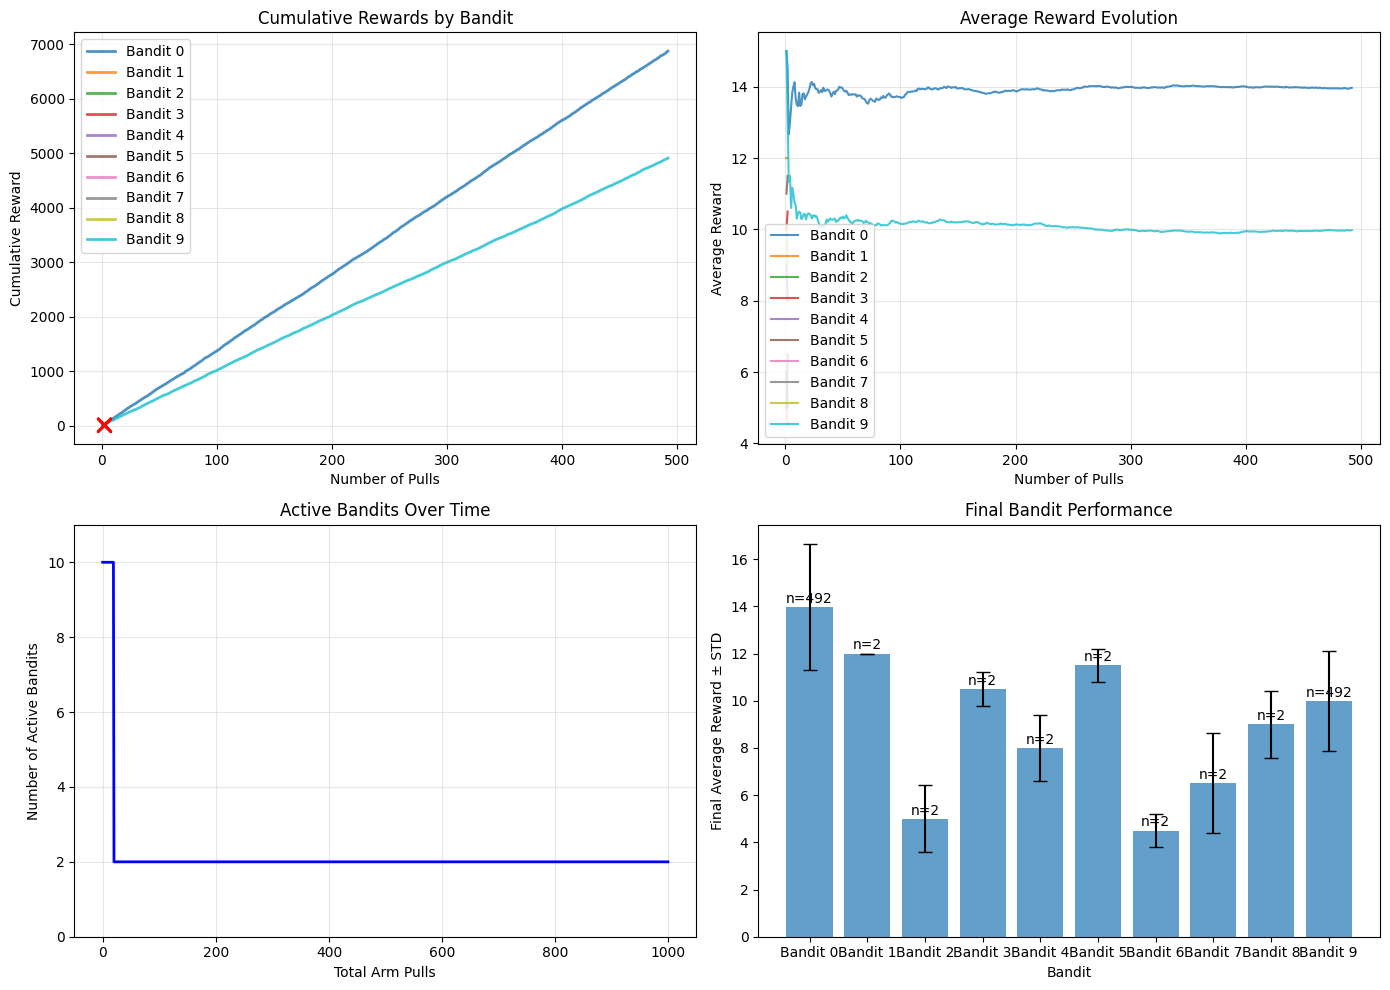

Average reward: 11.9150
Average reward: 10.7040


In [8]:
# Usage
K = 10
T = 1000
reward = Adaptive_Elimination(K, T, plot=True)
reward2 = Adaptive_Elimination2(K, T)
print(f"Average reward: {reward:.4f}")
print(f"Average reward: {reward2:.4f}")

#### UCB1

In [ ]:
def UCB1(K, T, plot=False):
    """
    Upper Confidence Bound (UCB1) algorithm implementation
    
    Parameters:
    K: number of bandits/arms
    T: total number of trials (arm pulls)
    plot: whether to plot the performance metrics
    
    Returns:
    average_reward: average reward per pull
    """
    
    # Initialize variables
    rewards = [[] for _ in range(K)]  # Store rewards for each arm
    cumulative_rewards = [0] * K     # Cumulative rewards per arm
    pull_counts = [0] * K            # Number of pulls per arm
    total_reward = 0                 # Total reward accumulated
    ucb_values_history = []          # Track UCB values over time
    selected_arms = []               # Track which arm was selected at each step
    
    # First, pull each arm once to initialize
    for k in range(K):
        if len(rewards[k]) >= T:  # Safety check
            break
        reward = myBandit.get_arm(k)
        rewards[k].append(reward)
        cumulative_rewards[k] += reward
        pull_counts[k] += 1
        total_reward += reward
        selected_arms.append(k)
    
    # Main UCB1 algorithm for remaining pulls
    for t in range(K, T):
        # Calculate UCB values for all arms
        ucb_values = []
        current_ucb_values = {}
        
        for k in range(K):
            if pull_counts[k] == 0:
                # If arm hasn't been pulled, give it infinite UCB to ensure it gets pulled
                ucb_value = float('inf')
            else:
                # Calculate average reward (mu_i)
                mu_i = cumulative_rewards[k] / pull_counts[k]
                
                # Calculate exploration term: sqrt(2 * ln(t) / t_i)
                exploration_term = np.sqrt(2 * np.log(t) / pull_counts[k])
                
                # UCB value = mu_i + exploration_term
                ucb_value = mu_i + exploration_term
            
            ucb_values.append(ucb_value)
            current_ucb_values[k] = ucb_value
        
        # Store UCB values for plotting
        ucb_values_history.append(current_ucb_values.copy())
        
        # Select arm with highest UCB value
        selected_arm = np.argmax(ucb_values)
        
        # Pull the selected arm
        reward = myBandit.get_arm(selected_arm)
        
        # Update statistics
        rewards[selected_arm].append(reward)
        cumulative_rewards[selected_arm] += reward
        pull_counts[selected_arm] += 1
        total_reward += reward
        selected_arms.append(selected_arm)
    
    # Calculate final average reward
    average_reward = total_reward / T
    
    if plot:
        plot_ucb_performance(rewards, pull_counts, ucb_values_history, selected_arms, K, T)
    
    return average_reward

def plot_ucb_performance(rewards, pull_counts, ucb_values_history, selected_arms, K, T):
    """Plot UCB1 algorithm performance metrics"""
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Cumulative rewards by arm
    plt.subplot(2, 2, 1)
    for k in range(K):
        if rewards[k]:  # Only plot arms that were pulled
            cumulative = np.cumsum(rewards[k])
            plt.plot(range(1, len(cumulative) + 1), cumulative, 
                    label=f'Arm {k} (n={pull_counts[k]})', linewidth=2)
    
    plt.xlabel('Number of Pulls')
    plt.ylabel('Cumulative Reward')
    plt.title('Cumulative Reward by Arm')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: UCB values evolution for selected arms
    plt.subplot(2, 2, 2)
    time_steps = range(K, T)
    
    # Plot UCB values for a subset of arms (to avoid clutter)
    arms_to_plot = min(5, K)  # Plot first 5 arms or all if less than 5
    for k in range(arms_to_plot):
        ucb_vals = [ucb_values_history[t-K][k] for t in time_steps if k in ucb_values_history[t-K]]
        if ucb_vals:
            plt.plot(time_steps[:len(ucb_vals)], ucb_vals, 
                    label=f'Arm {k} UCB', alpha=0.8, linewidth=2)
    
    plt.xlabel('Time Step (t)')
    plt.ylabel('UCB Value')
    plt.title('UCB Values Evolution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Arm selection frequency
    plt.subplot(2, 2, 3)
    arm_selections = [selected_arms.count(k) for k in range(K)]
    x_pos = np.arange(K)
    bars = plt.bar(x_pos, arm_selections, alpha=0.7)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height}', ha='center', va='bottom')
    
    plt.xlabel('Arm')
    plt.ylabel('Number of Selections')
    plt.title('Arm Selection Frequency')
    plt.xticks(x_pos, [f'Arm {i}' for i in range(K)])
    
    # Plot 4: Average reward and exploration/exploitation trade-off
    plt.subplot(2, 2, 4)
    
    # Calculate moving average of rewards
    all_rewards = []
    for arm_rewards in rewards:
        all_rewards.extend(arm_rewards)
    
    moving_avg = []
    for i in range(1, len(all_rewards) + 1):
        moving_avg.append(np.mean(all_rewards[:i]))
    
    plt.plot(range(1, len(moving_avg) + 1), moving_avg, 'b-', linewidth=2, label='Moving Average Reward')
    
    # Calculate exploration rate (percentage of pulls that are exploratory)
    exploration_rate = []
    optimal_arm = np.argmax([np.mean(rewards[k]) if rewards[k] else 0 for k in range(K)])
    
    for i in range(1, len(selected_arms) + 1):
        recent_selections = selected_arms[max(0, i-100):i]  # Last 100 selections
        exploration_count = sum(1 for arm in recent_selections if arm != optimal_arm)
        exploration_rate.append(exploration_count / len(recent_selections) * 100)
    
    plt.twinx()
    plt.plot(range(1, len(exploration_rate) + 1), exploration_rate, 'r-', alpha=0.7, label='Exploration Rate (%)')
    plt.ylabel('Exploration Rate (%)', color='red')
    plt.legend(loc='upper right')
    
    plt.xlabel('Time Step')
    plt.title('Reward Trend and Exploration Rate')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nUCB1 Algorithm Summary:")
    print("=" * 50)
    print(f"Total pulls: {T}")
    print(f"Total reward: {sum(sum(r) for r in rewards):.2f}")
    print(f"Average reward: {average_reward:.4f}")
    print(f"\nArm statistics:")
    for k in range(K):
        if pull_counts[k] > 0:
            avg_reward = cumulative_rewards[k] / pull_counts[k]
            print(f"Arm {k}: {pull_counts[k]} pulls, avg reward: {avg_reward:.4f}")
    
    optimal_arm = np.argmax([np.mean(rewards[k]) if rewards[k] else 0 for k in range(K)])
    optimal_pulls = pull_counts[optimal_arm]
    print(f"\nOptimal arm: {optimal_arm} ({optimal_pulls/T*100:.1f}% of pulls)")

# Alternative optimized version
def Optimized_UCB1(K, T):
    """
    Optimized UCB1 implementation with better memory efficiency
    """
    # Initialize arrays
    cumulative_rewards = np.zeros(K)
    pull_counts = np.zeros(K, dtype=int)
    total_reward = 0
    
    # Initialize each arm once
    for k in range(min(K, T)):
        reward = myBandit.get_arm(k)
        cumulative_rewards[k] += reward
        pull_counts[k] += 1
        total_reward += reward
    
    # Main UCB1 loop
    for t in range(K, T):
        # Calculate UCB values
        ucb_values = np.zeros(K)
        for k in range(K):
            if pull_counts[k] == 0:
                ucb_values[k] = float('inf')
            else:
                mu_i = cumulative_rewards[k] / pull_counts[k]
                exploration_term = np.sqrt(2 * np.log(t) / pull_counts[k])
                ucb_values[k] = mu_i + exploration_term
        
        # Select and pull arm
        selected_arm = np.argmax(ucb_values)
        reward = myBandit.get_arm(selected_arm)
        
        # Update statistics
        cumulative_rewards[selected_arm] += reward
        pull_counts[selected_arm] += 1
        total_reward += reward
    
    return total_reward / T

# Usage example
K = 10
T = 1000
reward = UCB1(K, T, plot=True)
print(f"UCB1 Average reward: {reward:.4f}")

# Compare with optimized version
reward_opt = Optimized_UCB1(K, T)
print(f"Optimized UCB1 Average reward: {reward_opt:.4f}")